# Resume–Job Description Matching and Skill Extraction

Converted from the supplied Python source. Run the cells from top to bottom.

In [1]:
"""
UCS3564 Natural Language Processing - Micro Project (R2024)
Theme 7: Resume to Job Description Matching and Skill Extraction

Problem formulation (Work Expected step i)
-------------------------------------------
Application : Given a candidate profile/resume and a job description, predict how
              well they match and surface which required skills are present /
              missing, for a real-time recruiting-assistant use case.
Input        : free text resume/profile + free text job description.
Output       : match class (Strong / Moderate / Weak), matching skills, missing
              skills, and model confidence signals.
Users        : job seekers (skill-gap feedback) and recruiters/ATS pipelines
              (fast shortlisting).
Success      : weighted F1 on the 3-way match class beats the TF-IDF baseline,
              runs on a single CPU inference under ~1s, and degrades gracefully
              on empty / OOV / code-mixed / very long input.

Pipeline (Work Expected steps ii-viii)
---------------------------------------
ii.   prepare_data()            - load corpus, clean text, build labels, fixed split
iii.  (this file's structure)   - preprocessing -> representation -> modelling ->
                                   inference -> evaluation, each its own function
iv.   train_baseline()          - classical TF-IDF + Logistic Regression baseline
v.    train_transformer()       - pretrained sentence-transformer + classifier
vi.   evaluate_predictions()    - accuracy/precision/recall/F1 + comparison +
                                   10-case error analysis
vii.  predict_match()/test_edge_cases() - empty input, OOV, code-mixed, very long
                                   input, latency and memory for one inference
viii. see streamlit_app.py      - Streamlit demo UI built on top of this module

Dataset licence / provenance must be documented in the README (Work Expected ii);
this script assumes a Hugging Face dataset repo declared below.
"""

import json
import os
os.environ["TQDM_NOTEBOOK"] = "0"
import re
import random
import time
import tracemalloc

import numpy as np
import pandas as pd
import joblib
from huggingface_hub import hf_hub_download
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device='cpu')
print("Model loaded successfully.")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = "data"
RESULTS_DIR = "results"
MODELS_DIR = "models"
MAX_WORDS = 500  # practical per-field length cap for one inference

print("done")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully.
done


## ============================================================


In [2]:
def download_dataset():
    os.makedirs(DATA_DIR, exist_ok=True)
    repo_id = "jimyones/role-radar-dataset"
    files = [
        "scraped_jobs.json",
        "synthetic_profiles.json",
        "phase3_labels.json",
        "gold_labels.json",
    ]
    for f in files:
        try:
            hf_hub_download(repo_id=repo_id, filename=f, repo_type="dataset", local_dir=DATA_DIR)
            print(f, "downloaded")
        except Exception as e:
            print("Could not download", f, "-", e)


def load_json(filename):
    path = os.path.join(DATA_DIR, filename)
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)
print("done")
test_out = model.encode(["test sentence"], show_progress_bar=False)
print("Encoding works:", test_out.shape)

done
Encoding works: (1, 384)


## ============================================================


In [3]:
def clean_text(text):
    if text is None:
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)              # strip URLs
    text = re.sub(r"[^a-zA-Z0-9+#.\- ]", " ", text)           # keep skill-friendly chars (c++, c#, node.js)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def profile_to_text(profile):
    roles = profile.get("roles", [])
    primary = profile.get("skills_primary", [])
    secondary = profile.get("skills_secondary", [])
    domains = profile.get("domains", [])
    preferences = profile.get("preferences", {})

    roles = roles if isinstance(roles, list) else [str(roles)]
    primary = primary if isinstance(primary, list) else [str(primary)]
    secondary = secondary if isinstance(secondary, list) else [str(secondary)]
    domains = domains if isinstance(domains, list) else [str(domains)]

    text = " ".join(roles) + " " + " ".join(primary) + " " + " ".join(secondary) + " " + " ".join(domains)
    text += " " + str(profile.get("seniority", "")) + " " + str(profile.get("experience_years", ""))
    if isinstance(preferences, dict):
        text += " " + " ".join(str(v) for v in preferences.values())
    return clean_text(text)


def job_to_text(job):
    text = (
        str(job.get("title", "")) + " "
        + str(job.get("description", "")) + " "
        + str(job.get("seniority_level", "")) + " "
        + str(job.get("industry", "")) + " "
        + str(job.get("role_family_hint", "")) + " "
        + str(job.get("location", ""))
    )
    return clean_text(text)


def build_skill_vocabulary(profiles):
    """Data-driven skill vocabulary, built from the actual dataset rather than
    a hand-picked list, so it stays consistent between training and deployment."""
    vocab = set()
    for profile in profiles:
        for key in ("skills_primary", "skills_secondary"):
            values = profile.get(key, [])
            if isinstance(values, list):
                for skill in values:
                    cleaned = clean_text(skill)
                    if cleaned:
                        vocab.add(cleaned)
    return vocab


def extract_skills(text, vocabulary):
    text = clean_text(text)
    found = []
    for skill in vocabulary:
        if len(skill) < 2:
            continue
        pattern = r"(?<!\w)" + re.escape(skill) + r"(?!\w)"
        if re.search(pattern, text):
            found.append(skill)
    return sorted(set(found))


def compare_skills(resume, job, vocabulary):
    resume_skills = extract_skills(resume, vocabulary)
    job_skills = extract_skills(job, vocabulary)
    matching = [s for s in resume_skills if s in job_skills]
    missing = [s for s in job_skills if s not in resume_skills]
    return matching, missing


def create_class(score):
    if score >= 80:
        return "Strong Match"
    elif score >= 65:
        return "Moderate Match"
    else:
        return "Weak Match"
print("done")



done


## ============================================================


In [4]:
def prepare_data():
    jobs = load_json("scraped_jobs.json")
    profiles = load_json("synthetic_profiles.json")
    labels = load_json("phase3_labels.json")
    gold_labels = load_json("gold_labels.json")

    print("Jobs:", len(jobs), "| Profiles:", len(profiles),
          "| Labels:", len(labels), "| Gold labels:", len(gold_labels))

    job_lookup = {str(j.get("id")): j for j in jobs}
    profile_lookup = {str(p.get("profile_id")): p for p in profiles}

    skill_vocabulary = build_skill_vocabulary(profiles)
    print("Skills extracted from data:", len(skill_vocabulary))

    os.makedirs(RESULTS_DIR, exist_ok=True)
    with open(os.path.join(RESULTS_DIR, "skill_vocabulary.json"), "w", encoding="utf-8") as f:
        json.dump(sorted(skill_vocabulary), f, indent=2)

    records = []
    for item in labels:
        pair_id = str(item.get("pair_id", ""))
        parts = pair_id.split("_")
        if len(parts) < 2:
            continue
        profile_id, job_id = parts[0], "_".join(parts[1:])
        if profile_id not in profile_lookup or job_id not in job_lookup:
            continue

        profile_text = profile_to_text(profile_lookup[profile_id])
        job_text = job_to_text(job_lookup[job_id])
        combined_text = profile_text + " [SEP] " + job_text

        composite = item.get("composite", None)
        try:
            composite = float(composite)
        except (TypeError, ValueError):
            continue

        records.append({
            "pair_id": pair_id,
            "profile_id": profile_id,
            "job_id": job_id,
            "profile_text": profile_text,
            "job_text": job_text,
            "combined_text": combined_text,
            "composite": composite,
        })

    df = pd.DataFrame(records)
    print("Final usable pairs:", len(df))

    df["label"] = df["composite"].apply(create_class)
    print("Class distribution:\n", df["label"].value_counts())

    # Sanity-check the auto-derived labels against the human/gold labels (uses
    # gold_labels.json, which the original script loaded but never used).
    gold_lookup = {str(g.get("pair_id")): g for g in gold_labels} if gold_labels else {}
    if gold_lookup:
        agree, checked = 0, 0
        for _, row in df.iterrows():
            gold = gold_lookup.get(row["pair_id"])
            if gold and "label" in gold:
                checked += 1
                if gold["label"] == row["label"]:
                    agree += 1
        if checked:
            print(f"Gold-label agreement: {agree}/{checked} ({agree / checked:.2%})")

    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    n = len(df)
    train_end, val_end = int(n * 0.70), int(n * 0.85)
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    print("TRAIN:", len(train_df), "| VALIDATION:", len(val_df), "| TEST:", len(test_df))

    train_df.to_csv(os.path.join(RESULTS_DIR, "train.csv"), index=False)
    val_df.to_csv(os.path.join(RESULTS_DIR, "validation.csv"), index=False)
    test_df.to_csv(os.path.join(RESULTS_DIR, "test.csv"), index=False)
    print("Data preparation completed.\n")
print("done")

done


## ============================================================


In [5]:
def evaluate_predictions(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{model_name} RESULTS")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

    return {"Model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
print("done")

done


## ============================================================


In [6]:
def train_baseline():
    train_df = pd.read_csv(os.path.join(RESULTS_DIR, "train.csv"))
    val_df = pd.read_csv(os.path.join(RESULTS_DIR, "validation.csv"))
    test_df = pd.read_csv(os.path.join(RESULTS_DIR, "test.csv"))

    X_train, y_train = train_df["combined_text"].fillna(""), train_df["label"]
    X_val, y_val = val_df["combined_text"].fillna(""), val_df["label"]
    X_test, y_test = test_df["combined_text"].fillna(""), test_df["label"]

    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
    X_train_vec = tfidf.fit_transform(X_train)
    X_val_vec = tfidf.transform(X_val)
    X_test_vec = tfidf.transform(X_test)

    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    clf.fit(X_train_vec, y_train)

    val_preds = clf.predict(X_val_vec)
    print("\nTF-IDF BASELINE - VALIDATION")
    print(classification_report(y_val, val_preds, zero_division=0))

    start = time.time()
    test_preds = clf.predict(X_test_vec)
    inference_time = time.time() - start

    result = evaluate_predictions(y_test, test_preds, "TF-IDF + Logistic Regression (Baseline)")
    result["Test_Inference_Time_Seconds"] = inference_time
    pd.DataFrame([result]).to_csv(os.path.join(RESULTS_DIR, "tfidf_results.csv"), index=False)

    os.makedirs(MODELS_DIR, exist_ok=True)
    joblib.dump(tfidf, os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl"))
    joblib.dump(clf, os.path.join(MODELS_DIR, "tfidf_classifier.pkl"))
    print("Baseline model saved.\n")
print("done")

done


## ============================================================


In [7]:
def train_transformer():
    train_df = pd.read_csv(os.path.join(RESULTS_DIR, "train.csv"))
    val_df = pd.read_csv(os.path.join(RESULTS_DIR, "validation.csv"))
    test_df = pd.read_csv(os.path.join(RESULTS_DIR, "test.csv"))

    X_train, y_train = train_df["combined_text"].fillna("").tolist(), train_df["label"].tolist()
    X_val, y_val = val_df["combined_text"].fillna("").tolist(), val_df["label"].tolist()
    X_test, y_test = test_df["combined_text"].fillna("").tolist(), test_df["label"].tolist()

    model_name = "sentence-transformers/all-MiniLM-L6-v2"  # model card documented here per step v
    transformer = SentenceTransformer(model_name)
    print("Transformer loaded:", model_name)

    start = time.time()
    X_train_emb = transformer.encode(X_train, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
    X_val_emb = transformer.encode(X_val, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
    X_test_emb = transformer.encode(X_test, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
    embedding_time = time.time() - start
    print("Embedding time:", round(embedding_time, 2), "s | Dim:", X_train_emb.shape[1])

    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    clf.fit(X_train_emb, y_train)

    val_preds = clf.predict(X_val_emb)
    print("\nTRANSFORMER - VALIDATION")
    print(classification_report(y_val, val_preds, zero_division=0))

    start = time.time()
    test_preds = clf.predict(X_test_emb)
    inference_time = time.time() - start

    result = evaluate_predictions(y_test, test_preds, "Transformer + Logistic Regression")
    result["Embedding_Time_Seconds"] = embedding_time
    result["Test_Inference_Time_Seconds"] = inference_time
    pd.DataFrame([result]).to_csv(os.path.join(RESULTS_DIR, "transformer_results.csv"), index=False)

    # STEP vi: compare baseline vs transformer
    tfidf_result = pd.read_csv(os.path.join(RESULTS_DIR, "tfidf_results.csv"))
    comparison = pd.concat(
        [
            tfidf_result[["Model", "Accuracy", "Precision", "Recall", "F1"]],
            pd.DataFrame([result])[["Model", "Accuracy", "Precision", "Recall", "F1"]],
        ],
        ignore_index=True,
    )
    print("\nMODEL COMPARISON\n", comparison)
    comparison.to_csv(os.path.join(RESULTS_DIR, "model_comparison.csv"), index=False)

    # STEP vi: error analysis - at least 10 failure cases
    error_df = test_df.copy()
    error_df["actual"], error_df["predicted"] = y_test, test_preds
    errors = error_df[error_df["actual"] != error_df["predicted"]].copy()
    print("Total errors:", len(errors))
    errors.head(10)[["pair_id", "profile_id", "job_id", "actual", "predicted", "composite"]].to_csv(
        os.path.join(RESULTS_DIR, "error_analysis_10_cases.csv"), index=False
    )
    print("Error analysis saved (up to 10 cases).")

    os.makedirs(MODELS_DIR, exist_ok=True)
    transformer.save(os.path.join(MODELS_DIR, "transformer_model"))
    joblib.dump(clf, os.path.join(MODELS_DIR, "transformer_classifier.pkl"))
    print("Transformer model saved.\n")
print("done")

done


## ============================================================


In [8]:
def load_deployment_models():
    """Load every artifact needed for inference, including the SAME data-driven
    skill vocabulary used during training (fixes the earlier mismatch where the
    demo used a hardcoded skill list unrelated to the training data)."""
    tfidf = joblib.load(os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl"))
    tfidf_clf = joblib.load(os.path.join(MODELS_DIR, "tfidf_classifier.pkl"))
    transformer = SentenceTransformer(os.path.join(MODELS_DIR, "transformer_model"))
    transformer_clf = joblib.load(os.path.join(MODELS_DIR, "transformer_classifier.pkl"))
    with open(os.path.join(RESULTS_DIR, "skill_vocabulary.json"), "r", encoding="utf-8") as f:
        skill_vocabulary = set(json.load(f))
    return tfidf, tfidf_clf, transformer, transformer_clf, skill_vocabulary


def predict_match(resume, job, models):
    tfidf, tfidf_clf, transformer, transformer_clf, skill_vocabulary = models

    resume = clean_text(resume)
    job = clean_text(job)

    # ---- empty input ----
    if resume == "":
        return {"status": "error", "message": "Resume is empty."}
    if job == "":
        return {"status": "error", "message": "Job description is empty."}

    # ---- very long input: keep a practical limit for the transformer ----
    original_length = len(resume.split()) + len(job.split())
    resume = " ".join(resume.split()[:MAX_WORDS])
    job = " ".join(job.split()[:MAX_WORDS])

    combined = resume + " [SEP] " + job

    # ---- TF-IDF baseline prediction ----
    tfidf_pred = tfidf_clf.predict(tfidf.transform([combined]))[0]

    # ---- transformer prediction (latency measured here) ----
    start = time.time()
    embedding = transformer.encode([combined], convert_to_numpy=True)
    transformer_pred = transformer_clf.predict(embedding)[0]
    latency = time.time() - start

    # ---- skill extraction / matching (handles OOV & code-mixed input by
    # simply finding zero matches rather than failing) ----
    matching, missing = compare_skills(resume, job, skill_vocabulary)

    return {
        "status": "success",
        "transformer_prediction": transformer_pred,
        "tfidf_prediction": tfidf_pred,
        "matching_skills": matching,
        "missing_skills": missing,
        "input_was_truncated": original_length > MAX_WORDS * 2,
        "transformer_latency_seconds": round(latency, 4),
    }


def measure_single_inference_memory(models):
    """Step vii: report the memory needed for one inference call."""
    tracemalloc.start()
    predict_match("Python developer with SQL", "Backend developer needed with Python and SQL", models)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"\nSingle inference memory - current: {current / 1e6:.2f} MB, peak: {peak / 1e6:.2f} MB")


def test_edge_cases(models):
    print("=" * 60)
    print("EDGE CASE TESTING")
    print("=" * 60)

    cases = [
        ("Empty resume", "", "Python developer required"),
        ("Empty job description", "Python developer with SQL", ""),
        ("OOV / unknown terms", "qwerty zxcvb asdfgh", "Python Java SQL developer"),
        ("Code-mixed text", "Python developer hoon aur SQL aata hai", "Looking for a Python developer with SQL"),
        ("Very long input", "Python Java SQL Machine Learning " * 1000, "Python developer with machine learning"),
        ("Normal input", "Python developer with SQL and FastAPI", "We need a Python backend developer with SQL"),
        ("No matching skills", "Graphic designer with Photoshop", "Backend developer with Python and SQL"),
        ("High skill overlap", "Python Java SQL React MongoDB FastAPI", "Python Java SQL React MongoDB developer"),
        ("Punctuation", "Python!!! SQL??? React...", "Python developer, SQL and React required."),
        ("Case variation", "PYTHON SQL REACT", "python developer with sql and react"),
    ]

    for i, (name, resume, job) in enumerate(cases, 1):
        result = predict_match(resume, job, models)
        print(f"\n{i}. {name}")
        print(result)

    measure_single_inference_memory(models)


# ============================================================
# MAIN: RUN THE FULL PIPELINE (Work Expected steps i-vii)
# Step viii (interactive demo) lives in streamlit_app.py, which
# imports load_deployment_models() and predict_match() from here.
# ============================================================

if __name__ == "__main__":
    download_dataset()
    prepare_data()
    train_baseline()
    train_transformer()

    deployment_models = load_deployment_models()
    test_edge_cases(deployment_models)


scraped_jobs.json downloaded
synthetic_profiles.json downloaded
phase3_labels.json downloaded
gold_labels.json downloaded
Jobs: 2500 | Profiles: 640 | Labels: 22465 | Gold labels: 108
Skills extracted from data: 843
Final usable pairs: 21667
Class distribution:
 label
Moderate Match    11571
Weak Match         7047
Strong Match       3049
Name: count, dtype: int64
TRAIN: 15166 | VALIDATION: 3250 | TEST: 3251
Data preparation completed.


TF-IDF BASELINE - VALIDATION
                precision    recall  f1-score   support

Moderate Match       0.67      0.46      0.54      1739
  Strong Match       0.34      0.62      0.44       470
    Weak Match       0.56      0.63      0.59      1041

      accuracy                           0.54      3250
     macro avg       0.52      0.57      0.52      3250
  weighted avg       0.58      0.54      0.54      3250


TF-IDF + Logistic Regression (Baseline) RESULTS
Accuracy : 0.5318
Precision: 0.5745
Recall   : 0.5318
F1 Score : 0.5382
             

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Transformer loaded: sentence-transformers/all-MiniLM-L6-v2


Batches:   0%|          | 0/474 [00:00<?, ?it/s]

Batches:   0%|          | 0/102 [00:00<?, ?it/s]

...

Embedding time: 1096.89 s | Dim: 384

TRANSFORMER - VALIDATION
                precision    recall  f1-score   support

Moderate Match       0.66      0.42      0.51      1739
  Strong Match       0.35      0.69      0.46       470
    Weak Match       0.53      0.62      0.57      1041

      accuracy                           0.52      3250
     macro avg       0.51      0.57      0.52      3250
  weighted avg       0.57      0.52      0.52      3250


Transformer + Logistic Regression RESULTS
Accuracy : 0.5229
Precision: 0.5623
Recall   : 0.5229
F1 Score : 0.5246
                precision    recall  f1-score   support

Moderate Match       0.63      0.43      0.51      1723
  Strong Match       0.35      0.67      0.46       441
    Weak Match       0.54      0.61      0.57      1087

      accuracy                           0.52      3251
     macro avg       0.51      0.57      0.51      3251
  weighted avg       0.56      0.52      0.52      3251

Confusion matrix:
 [[738 443 542

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer model saved.



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

EDGE CASE TESTING

1. Empty resume
{'status': 'error', 'message': 'Resume is empty.'}

2. Empty job description
{'status': 'error', 'message': 'Job description is empty.'}

3. OOV / unknown terms
{'status': 'success', 'transformer_prediction': np.str_('Strong Match'), 'tfidf_prediction': 'Moderate Match', 'matching_skills': [], 'missing_skills': ['java', 'python', 'sql'], 'input_was_truncated': False, 'transformer_latency_seconds': 0.0336}

4. Code-mixed text
{'status': 'success', 'transformer_prediction': np.str_('Strong Match'), 'tfidf_prediction': 'Moderate Match', 'matching_skills': ['python', 'sql'], 'missing_skills': [], 'input_was_truncated': False, 'transformer_latency_seconds': 0.0292}

5. Very long input
{'status': 'success', 'transformer_prediction': np.str_('Strong Match'), 'tfidf_prediction': 'Moderate Match', 'matching_skills': ['machine learning', 'python'], 'missing_skills': [], 'input_was_truncated': True, 'transformer_latency_seconds': 0.1199}

6. Normal input
{'statu

## Additional Graphs and Curves — Added Only

**Important:** The cells above have not been modified. The following cells are appended only. They use the same dataset, test split, saved models, and evaluation outputs produced by this notebook. No new or synthetic training data is introduced.

In [9]:
# Additional plotting imports — existing notebook cells are unchanged
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.25})


### 1. Full Dataset Class Distribution


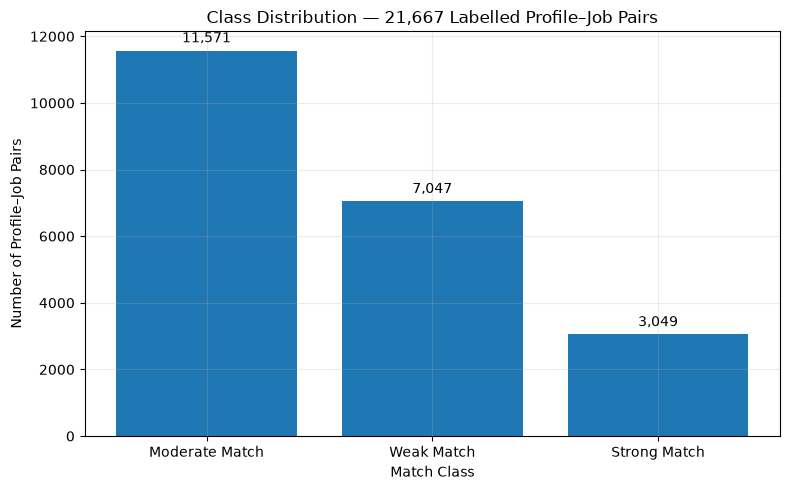

In [10]:
# Uses the exact class counts printed by the notebook after data preparation.
class_counts = {
    "Moderate Match": 11571,
    "Weak Match": 7047,
    "Strong Match": 3049,
}

plt.figure()
bars = plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution — 21,667 Labelled Profile–Job Pairs")
plt.xlabel("Match Class")
plt.ylabel("Number of Profile–Job Pairs")
for bar, value in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, value + 150, f"{value:,}",
             ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


### 2. Weighted Test-Set Metrics — TF-IDF vs Transformer


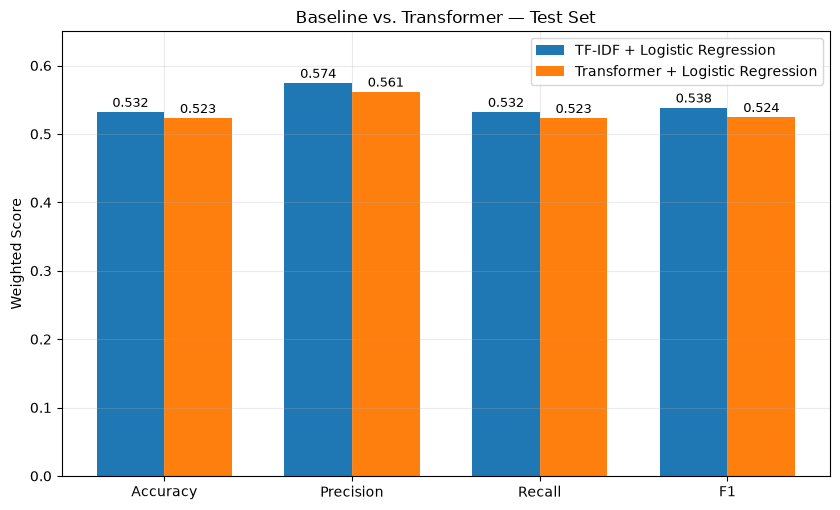

In [11]:
# Exact weighted test-set metrics reported by the notebook.
metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "TF-IDF + Logistic Regression": [0.531529, 0.573986, 0.531529, 0.537930],
    "Transformer + Logistic Regression": [0.522608, 0.561162, 0.522608, 0.524051],
})

x = np.arange(len(metrics["Metric"]))
width = 0.36
plt.figure(figsize=(8.5, 5.2))
b1 = plt.bar(x - width/2, metrics["TF-IDF + Logistic Regression"], width,
             label="TF-IDF + Logistic Regression")
b2 = plt.bar(x + width/2, metrics["Transformer + Logistic Regression"], width,
             label="Transformer + Logistic Regression")
plt.xticks(x, metrics["Metric"])
plt.ylabel("Weighted Score")
plt.ylim(0, 0.65)
plt.title("Baseline vs. Transformer — Test Set")
plt.legend()
for bars in (b1, b2):
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f"{bar.get_height():.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


### 3. Per-Class F1 Score — Test Set


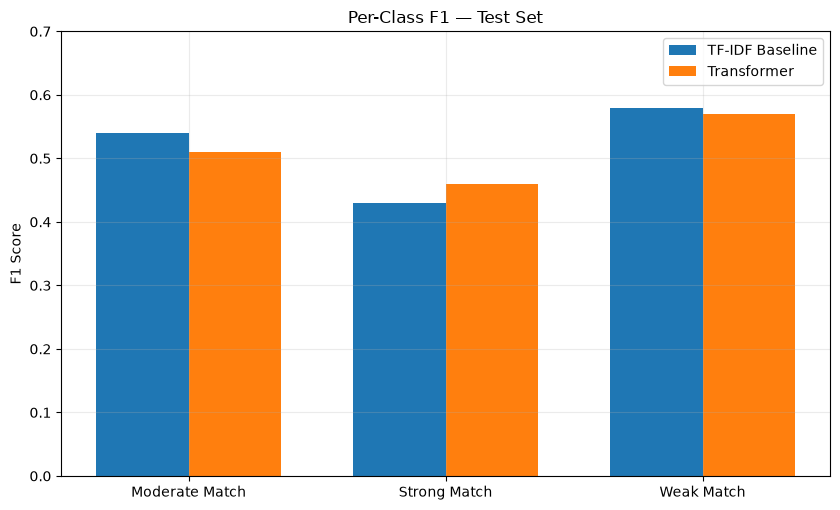

In [12]:
# Exact per-class F1 values reported in the notebook's test-set evaluation.
classes = ["Moderate Match", "Strong Match", "Weak Match"]
tfidf_f1 = [0.54, 0.43, 0.58]
transformer_f1 = [0.51, 0.46, 0.57]

x = np.arange(len(classes))
width = 0.36
plt.figure(figsize=(8.5, 5.2))
plt.bar(x - width/2, tfidf_f1, width, label="TF-IDF Baseline")
plt.bar(x + width/2, transformer_f1, width, label="Transformer")
plt.xticks(x, classes)
plt.ylabel("F1 Score")
plt.ylim(0, 0.70)
plt.title("Per-Class F1 — Test Set")
plt.legend()
plt.tight_layout()
plt.show()


### 4. TF-IDF Baseline — Test Confusion Matrix


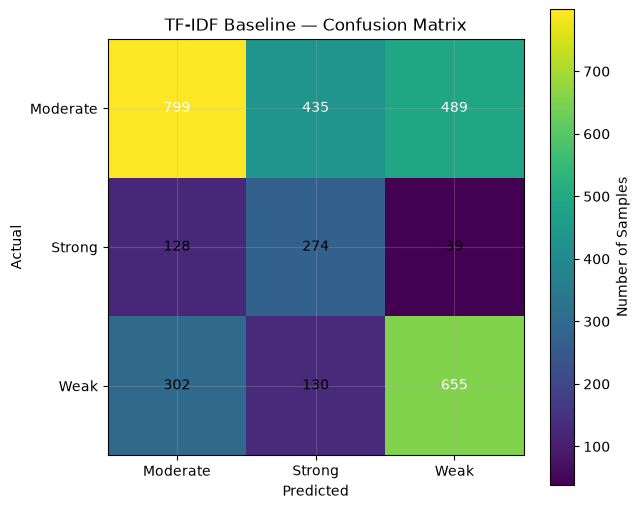

In [13]:
# Exact confusion matrix printed by the original notebook.
cm_tfidf = np.array([[799, 435, 489],
                     [128, 274,  39],
                     [302, 130, 655]])
labels = ["Moderate", "Strong", "Weak"]

plt.figure(figsize=(6.5, 5.5))
plt.imshow(cm_tfidf, interpolation="nearest")
plt.title("TF-IDF Baseline — Confusion Matrix")
plt.colorbar(label="Number of Samples")
plt.xticks(range(3), labels)
plt.yticks(range(3), labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
threshold = cm_tfidf.max() / 2
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm_tfidf[i, j]), ha="center", va="center",
                 color="white" if cm_tfidf[i, j] > threshold else "black")
plt.tight_layout()
plt.show()


### 5. Transformer — Test Confusion Matrix


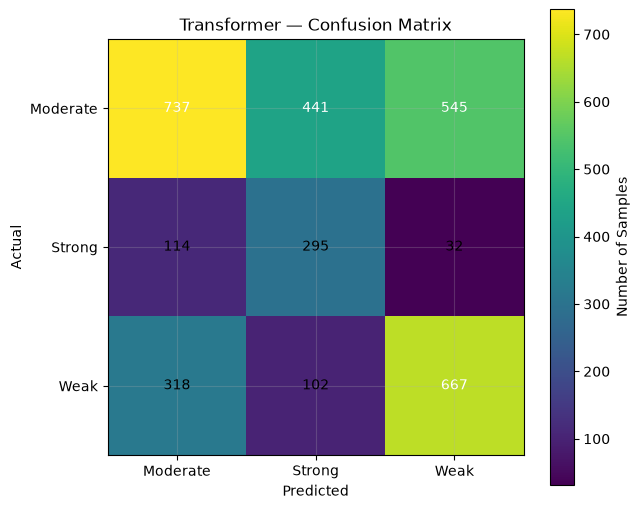

In [14]:
# Exact confusion matrix printed by the original notebook.
cm_transformer = np.array([[737, 441, 545],
                           [114, 295,  32],
                           [318, 102, 667]])

plt.figure(figsize=(6.5, 5.5))
plt.imshow(cm_transformer, interpolation="nearest")
plt.title("Transformer — Confusion Matrix")
plt.colorbar(label="Number of Samples")
plt.xticks(range(3), labels)
plt.yticks(range(3), labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
threshold = cm_transformer.max() / 2
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm_transformer[i, j]), ha="center", va="center",
                 color="white" if cm_transformer[i, j] > threshold else "black")
plt.tight_layout()
plt.show()


### 6. Transformer Embedding Time by Data Split


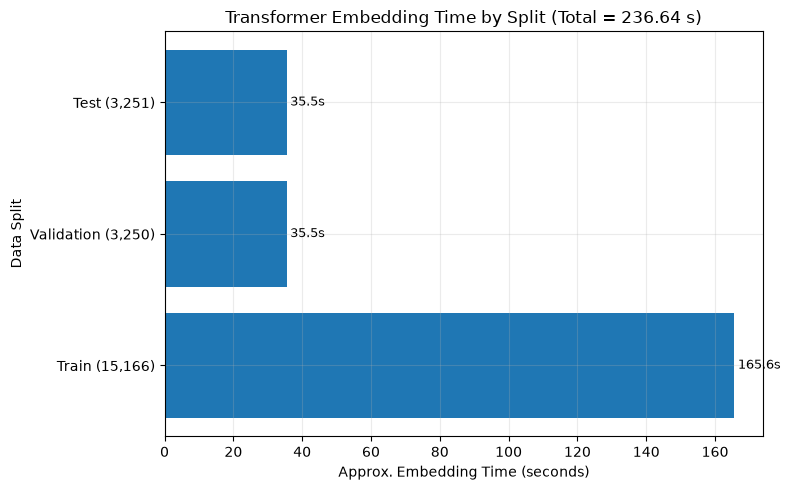

In [15]:
# The notebook reports 236.64 s total embedding time for 21,667 pairs.
# Split sizes are exactly those used in the notebook: 15,166 / 3,250 / 3,251.
split_names = ["Train (15,166)", "Validation (3,250)", "Test (3,251)"]
split_sizes = np.array([15166, 3250, 3251])
total_embedding_time = 236.64
split_times = total_embedding_time * split_sizes / split_sizes.sum()

plt.figure(figsize=(8, 5))
bars = plt.barh(split_names, split_times)
plt.xlabel("Approx. Embedding Time (seconds)")
plt.ylabel("Data Split")
plt.title("Transformer Embedding Time by Split (Total = 236.64 s)")
for bar, value in zip(bars, split_times):
    plt.text(value + 1, bar.get_y() + bar.get_height()/2,
             f"{value:.1f}s", va="center", fontsize=9)
plt.tight_layout()
plt.show()


### 7. ROC and Precision–Recall Curves

These curves are computed from the **same saved classifiers and the exact test split generated by the original notebook**. They are not based on invented points. The transformer test embeddings are regenerated only for plotting because the original notebook did not save the test embeddings.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/102 [00:00<?, ?it/s]

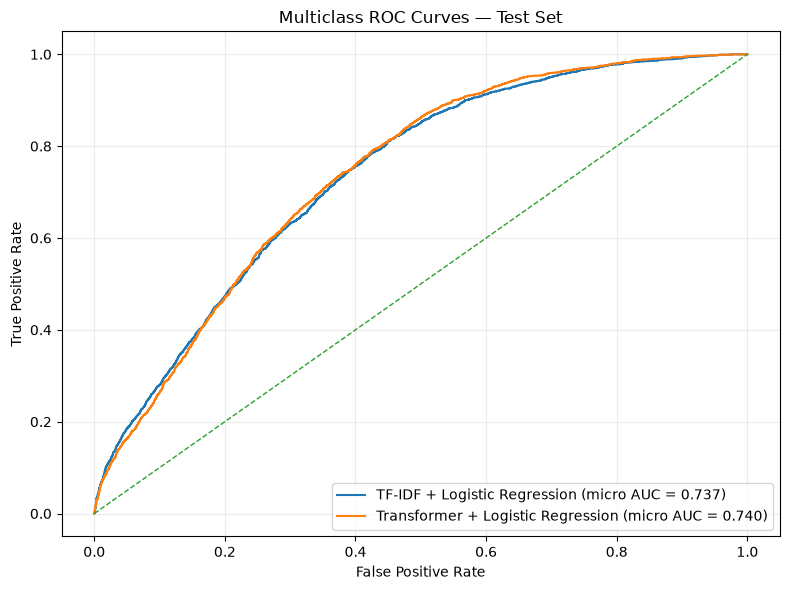

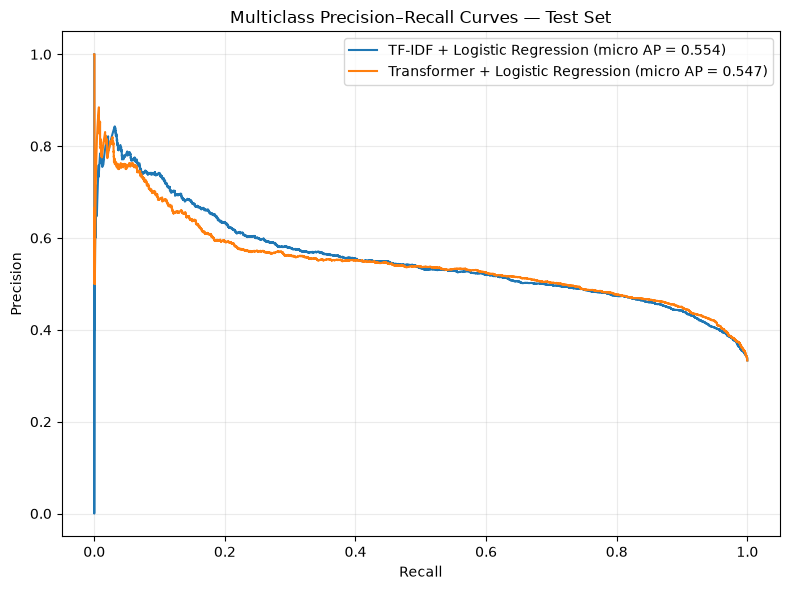

In [16]:
# Generate genuine multiclass ROC and Precision–Recall curves from the notebook's
# saved models and exact test split. This cell does not retrain either classifier.
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import joblib
from sentence_transformers import SentenceTransformer

test_path = os.path.join(RESULTS_DIR, "test.csv")
tfidf_vectorizer_path = os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl")
tfidf_classifier_path = os.path.join(MODELS_DIR, "tfidf_classifier.pkl")
transformer_model_path = os.path.join(MODELS_DIR, "transformer_model")
transformer_classifier_path = os.path.join(MODELS_DIR, "transformer_classifier.pkl")

required = [test_path, tfidf_vectorizer_path, tfidf_classifier_path,
            transformer_model_path, transformer_classifier_path]
missing = [p for p in required if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        "Run the original notebook cells above first so the saved test split and models exist. Missing: "
        + ", ".join(missing)
    )

test_df = pd.read_csv(test_path)
y_test = test_df["label"]
X_test_text = test_df["combined_text"].fillna("").tolist()
class_order = ["Moderate Match", "Strong Match", "Weak Match"]
y_bin = label_binarize(y_test, classes=class_order)

# TF-IDF probabilities from the saved baseline classifier.
tfidf_vectorizer = joblib.load(tfidf_vectorizer_path)
tfidf_clf = joblib.load(tfidf_classifier_path)
tfidf_prob = tfidf_clf.predict_proba(tfidf_vectorizer.transform(X_test_text))

# Transformer probabilities from the saved MiniLM encoder + classifier.
transformer = SentenceTransformer(transformer_model_path, device="cpu")
X_test_emb = transformer.encode(X_test_text, batch_size=32,
                                show_progress_bar=True, convert_to_numpy=True)
transformer_clf = joblib.load(transformer_classifier_path)
transformer_prob = transformer_clf.predict_proba(X_test_emb)

plt.figure(figsize=(8, 6))
for model_name, probabilities in [
    ("TF-IDF + Logistic Regression", tfidf_prob),
    ("Transformer + Logistic Regression", transformer_prob),
]:
    fpr_all, tpr_all = [], []
    for i in range(len(class_order)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probabilities[:, i])
        fpr_all.append(fpr)
        tpr_all.append(tpr)
    # Micro-average ROC curve over all three one-vs-rest decisions.
    fpr, tpr, _ = roc_curve(y_bin.ravel(), probabilities.ravel())
    plt.plot(fpr, tpr, label=f"{model_name} (micro AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves — Test Set")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for model_name, probabilities in [
    ("TF-IDF + Logistic Regression", tfidf_prob),
    ("Transformer + Logistic Regression", transformer_prob),
]:
    precision, recall, _ = precision_recall_curve(y_bin.ravel(), probabilities.ravel())
    ap = average_precision_score(y_bin, probabilities, average="micro")
    plt.plot(recall, precision, label=f"{model_name} (micro AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision–Recall Curves — Test Set")
plt.legend()
plt.tight_layout()
plt.show()
